# Skeletal Posture Analysis of Goalkeepers in Football

In this section, we will analyse the skeletal postures of goalkeepers during their game. We will try to cluster them based on the representations learnt from the our Cross-View Contrastive Learning (CVCL) model. We will also try to visualise the clusters in 3D using UMAP.

## Load Model and Embeddings (Representations)

In [1]:
import torch
from torchlight import import_class
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import os
import sys
import umap

sys.path.append(os.path.abspath('../utils'))
from analysis_utils import load_or_compute_embeddings
from plotting_utils import plot_interactive_umap_3d

/Users/kaushikk/Documents/All/University/ETH Zurich - Study/Y2S1/Semester Project/goalkeeping-skeletal/snfc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sys.path.append(os.path.abspath('../models/CrosSCLR'))
model_native = import_class('net.crossclr_3views.CrosSCLR')

# Must match config/CrosSCLR/fulltrain_3views.yaml
model_args_native = {
    'base_encoder': 'net.st_gcn.Model',
    'pretrain': True,
    'feature_dim': 128,
    'queue_size': 16384,
    'momentum': 0.999,
    'Temperature': 0.07,
    'mlp': True,
    'in_channels': 3,
    'hidden_channels': 16, # Note: Check if you changed this in config
    'hidden_dim': 256,
    'num_class': 60,
    'dropout': 0.5,
    'graph_args': {'layout': 'native', 'strategy': 'spatial'}, # CRITICAL CHANGE
    'edge_importance_weighting': True,
}

native_data_path = '../data/tensor_native'
work_dir_native = '../models/CrosSCLR/work_dir/crossclr_3views/fulltrain_goalkeeper_v1'

model_native = model_native(**model_args_native)
weights_path = f'{work_dir_native}/epoch300_model.pt' 

print(f"Loading weights from {weights_path}")
weights = torch.load(weights_path)
model_native.load_state_dict(weights, strict=False)
model_native.eval()
model_name = "fulltrain"

Loading weights from ../models/CrosSCLR/work_dir/crossclr_3views/fulltrain_goalkeeper_v1/epoch300_model.pt


In [14]:
N_native = 2000
split = 'train'

all_views_native, _, sampled_indices_native = load_or_compute_embeddings(
    model_native,
    dataset_name='snfc_native',
    N=N_native,
    model_name=model_name,
    split=split,
    return_indices=True,
)

X = all_views_native['motion'].cpu().numpy()
print(f"Embeddings Shape: {X.shape}")


Loading joint embeddings from ../models/CrosSCLR/embeddings/snfc_native_fulltrain_embeddings_train_joint_2000.pt
Loading motion embeddings from ../models/CrosSCLR/embeddings/snfc_native_fulltrain_embeddings_train_motion_2000.pt
Loading bone embeddings from ../models/CrosSCLR/embeddings/snfc_native_fulltrain_embeddings_train_bone_2000.pt
Loading all embeddings from ../models/CrosSCLR/embeddings/snfc_native_fulltrain_embeddings_train_all_2000.pt
All data loaded successfully.
Embeddings Shape: (2000, 128)


## Analyse Representations (Clustering and Visualisation)

In [15]:
umap_config = {
    'n_neighbors': 80,
    'min_dist': 0,
    'n_components': 5,
    'metric': 'cosine',
    'random_state': 42
}

hdbscan_config = {
    'min_cluster_size': 200,
    'min_samples': 3,
    'cluster_selection_epsilon': 0.0,
    'metric': 'euclidean'
}

Pick the embeddings from "all" view, which is the average of all three views' representations. 

## Clustering with tuned params

### Stage 1: Broad clustering — find the save cluster manually

In [16]:
import json

# ── Stage 1: Broad UMAP + HDBSCAN on ALL embeddings ────────────────────────────
# Goal: get a handful of coarse clusters. You inspect them visually
# (via visualize_tensor_sample.py) and pick the cluster(s) containing saves.

# Higher-dim UMAP for clustering
stage1_umap_hd = umap.UMAP(
    n_neighbors=50, min_dist=0.0, n_components=20,
    metric='cosine', random_state=42, n_jobs=1,
)
emb_hd = stage1_umap_hd.fit_transform(X)

# Broad HDBSCAN — larger min_cluster_size for coarse groups
stage1_hdbscan = HDBSCAN(
    min_cluster_size=50,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',   # coarser than 'leaf'
)
labels_stage1 = stage1_hdbscan.fit_predict(emb_hd)

# ── Load metadata for clip_type breakdown ──────────────────────────────────────
meta_path = f'{native_data_path}/{split}_metadata.json'
with open(meta_path, 'r') as f:
    all_meta = json.load(f)
clip_types = np.array([all_meta[i].get('clip_type', 'unknown') for i in sampled_indices_native])

# ── Print cluster distribution with action/idle breakdown ──────────────────────
unique_l, counts_l = np.unique(labels_stage1, return_counts=True)
print("Stage 1 cluster distribution:")
print(f"  {'Cluster':<10} {'Count':>6}  {'Action%':>8}  {'Idle%':>8}")
print(f"  {'-'*36}")
for l, c in sorted(zip(unique_l, counts_l)):
    tag = "NOISE" if l == -1 else f"Cluster {l}"
    mask = labels_stage1 == l
    n_action = np.sum(clip_types[mask] == 'action')
    n_idle = np.sum(clip_types[mask] == 'idle')
    pct_action = 100 * n_action / c
    pct_idle = 100 * n_idle / c
    print(f"  {tag:<10} {c:>6}  {pct_action:>7.1f}%  {pct_idle:>7.1f}%")

mask_cls = labels_stage1 != -1
if np.unique(labels_stage1[mask_cls]).size > 1:
    sil = silhouette_score(emb_hd[mask_cls], labels_stage1[mask_cls])
    print(f"\nSilhouette (excl. noise): {sil:.4f}")

# ── 3D visualisation ───────────────────────────────────────────────────────────
emb_3d = umap.UMAP(
    n_neighbors=50, min_dist=0.2, n_components=3,
    metric='cosine', random_state=42, n_jobs=1,
).fit_transform(X)

plot_interactive_umap_3d(
    emb_3d, labels_stage1,
    title="Stage 1 — Broad clusters (inspect & pick saves)",
    split=split,
    indices=sampled_indices_native,
)

# ── Print sample indices per cluster for quick inspection ──────────────────────
print("\nSample indices per cluster (use with visualize_tensor_sample.py):")
for cl in sorted(np.unique(labels_stage1)):
    cl_idx = sampled_indices_native[labels_stage1 == cl]
    tag = "NOISE" if cl == -1 else f"Cluster {cl}"
    preview = cl_idx[:8].tolist()
    print(f"  {tag} ({len(cl_idx)}): {preview}{'...' if len(cl_idx) > 8 else ''}")
    if cl != -1:
        print(f"    → python visualize_tensor_sample.py {preview[0]} --native")


Stage 1 cluster distribution:
  Cluster     Count   Action%     Idle%
  ------------------------------------
  NOISE         569     60.8%     39.2%
  Cluster 0     192     84.4%     15.6%
  Cluster 1      96     96.9%      3.1%
  Cluster 2      67    100.0%      0.0%
  Cluster 3      64     82.8%     17.2%
  Cluster 4     224     89.7%     10.3%
  Cluster 5     207     61.8%     38.2%
  Cluster 6     217      4.1%     95.9%
  Cluster 7      98     34.7%     65.3%
  Cluster 8     127     37.0%     63.0%
  Cluster 9     139     17.3%     82.7%

Silhouette (excl. noise): 0.5104



Sample indices per cluster (use with visualize_tensor_sample.py):
  NOISE (569): [4917, 9675, 40, 13201, 7670, 9300, 947, 10911]...
  Cluster 0 (192): [19351, 16180, 3712, 19276, 19014, 17343, 7027, 8161]...
    → python visualize_tensor_sample.py 19351 --native
  Cluster 1 (96): [11189, 1000, 9801, 16142, 14531, 4963, 2837, 11463]...
    → python visualize_tensor_sample.py 11189 --native
  Cluster 2 (67): [878, 6783, 2918, 15940, 4330, 16975, 8377, 18898]...
    → python visualize_tensor_sample.py 878 --native
  Cluster 3 (64): [1571, 6323, 1882, 2434, 15501, 5333, 8049, 4925]...
    → python visualize_tensor_sample.py 1571 --native
  Cluster 4 (224): [13922, 14353, 2500, 6675, 16859, 12672, 9344, 18937]...
    → python visualize_tensor_sample.py 13922 --native
  Cluster 5 (207): [14328, 14731, 11588, 9276, 2088, 2316, 5862, 5973]...
    → python visualize_tensor_sample.py 14328 --native
  Cluster 6 (217): [3689, 18229, 11954, 14716, 3285, 8470, 6352, 54]...
    → python visualize_te

Cluster 0: Moving back
Cluster 1: Kicks, CONSISTENT CLUSTER
Cluster 2: 
Cluster 3: Moving Around
Cluster 4: Sprinting

### Stage 2: Sub-cluster within the selected save cluster(s)
After inspecting the Stage 1 clusters (e.g. via `visualize_tensor_sample.py`), set `SAVE_CLUSTERS` below to the cluster label(s) that contain saves.

[0, 1, 2, 3, 4]   

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# ✏️  SET THIS after inspecting Stage 1 clusters
SAVE_CLUSTERS = [2]          # ← change to whatever cluster(s) contain saves
# ══════════════════════════════════════════════════════════════════════════════

# ── Filter to selected cluster(s) ──────────────────────────────────────────────
save_mask = np.isin(labels_stage1, SAVE_CLUSTERS)
X_saves = X[save_mask]
indices_saves = sampled_indices_native[save_mask]
clip_types_saves = clip_types[save_mask]
print(f"Selected {len(X_saves)} samples from cluster(s) {SAVE_CLUSTERS}")

# ── Stage 2 UMAP + HDBSCAN — finer clustering ─────────────────────────────────
stage2_umap_config = {
    'n_neighbors': 20,
    'min_dist': 0.0,
    'n_components': 40,
    'metric': 'cosine',
    'random_state': 42,
    'n_jobs': 1,
}
stage2_hdbscan_config = {
    'min_cluster_size': 5,
    'min_samples': 3,
    'metric': 'euclidean',
    'cluster_selection_method': 'eom',   # coarser than 'leaf'
}

emb_saves_hd = umap.UMAP(**stage2_umap_config).fit_transform(X_saves)
labels_saves = HDBSCAN(**stage2_hdbscan_config).fit_predict(emb_saves_hd)

unique_l2, counts_l2 = np.unique(labels_saves, return_counts=True)
print("\nStage 2 sub-cluster distribution:")
print(f"  {'Cluster':<10} {'Count':>6}  {'Action%':>8}")
print(f"  {'-'*28}")
for l, c in sorted(zip(unique_l2, counts_l2)):
    tag = "NOISE" if l == -1 else f"Cluster {l}"
    mask = labels_saves == l
    pct_action = 100 * np.sum(clip_types_saves[mask] == 'action') / c
    print(f"  {tag:<10} {c:>6}  {pct_action:>7.1f}%")

mask2 = labels_saves != -1
if np.unique(labels_saves[mask2]).size > 1:
    sil = silhouette_score(emb_saves_hd[mask2], labels_saves[mask2])
    print(f"\nSilhouette (excl. noise): {sil:.4f}")

# ── 3D visualisation ───────────────────────────────────────────────────────────
emb_saves_3d = umap.UMAP(**{**stage2_umap_config, 'n_components': 3}).fit_transform(X_saves)

plot_interactive_umap_3d(
    emb_saves_3d, labels_saves,
    title="Stage 2 — Save sub-clusters",
    split=split,
    indices=indices_saves,
)

Selected 175 samples from cluster(s) [2]

Stage 2 sub-cluster distribution:
  Cluster     Count   Action%
  ----------------------------
  NOISE           2     50.0%
  Cluster 0     132     90.2%
  Cluster 1      10     80.0%
  Cluster 2      26     76.9%
  Cluster 3       5     80.0%

Silhouette (excl. noise): 0.0741


- Cluster 0 (Red): Moving back

- Cluster 1 (Green): Running around

- Cluster 2 (Blue): Saves, Dives and Ready Poses

- Cluster 3 (Purple): Kicks


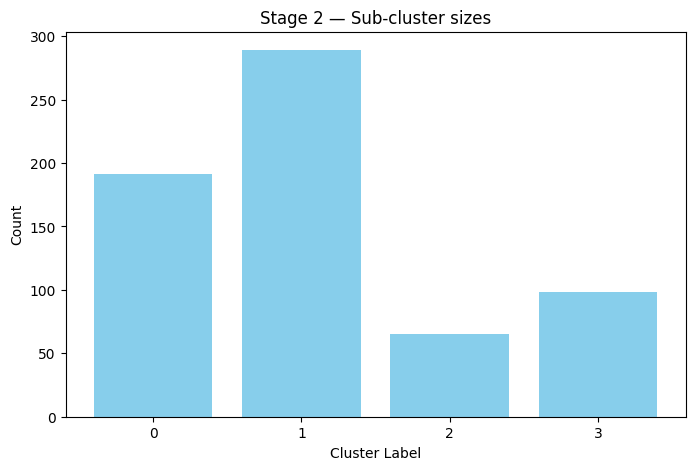

Cluster 0: 191 sequences
  Indices: [19351, 16180, 3712, 19276, 19014, 17343, 7027, 8161, 18022, 16748]...
  → python visualize_tensor_sample.py 19351 --native

Cluster 1: 289 sequences
  Indices: [13922, 14353, 2500, 6675, 16859, 1571, 6323, 12672, 9344, 18937]...
  → python visualize_tensor_sample.py 13922 --native

Cluster 2: 65 sequences
  Indices: [878, 6783, 2918, 15940, 4330, 16975, 8377, 18898, 6096, 18670]...
  → python visualize_tensor_sample.py 878 --native

Cluster 3: 98 sequences
  Indices: [11189, 1000, 9801, 16142, 14531, 4963, 2837, 11463, 14420, 3928]...
  → python visualize_tensor_sample.py 11189 --native



In [26]:
import pandas as pd

# ── Cluster distribution bar chart ─────────────────────────────────────────────
df_saves = pd.DataFrame({'index': indices_saves, 'label': labels_saves})
cluster_counts = df_saves['label'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color='skyblue')
plt.xlabel('Cluster Label')
plt.ylabel('Count')
plt.title('Stage 2 — Sub-cluster sizes')
plt.show()

# ── Per-cluster index listing ──────────────────────────────────────────────────
indices_by_cluster = df_saves.groupby('label')['index'].apply(list).to_dict()

for cl, cl_idx in sorted(indices_by_cluster.items()):
    tag = "NOISE" if cl == -1 else f"Cluster {cl}"
    print(f"{tag}: {len(cl_idx)} sequences")
    print(f"  Indices: {cl_idx[:10]}{'...' if len(cl_idx) > 10 else ''}")
    if cl != -1:
        print(f"  → python visualize_tensor_sample.py {cl_idx[0]} --native")
    print()

Cluster 0: A lot of moving around with no diving

Cluster 13: Not really interesting, couldn't find any saves in top 10 